# 01: Data audit

- **920** recordings, **6898** cycles split as **Normal 3642 / Crackle 1864 / Wheeze 886 / Both 506**.
- Device totals: **AKGC417L 646 · LittC2SE 87 · Litt3200 60 · Meditron 127**.
- Official train/test split: 539 / 381.


In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/safina57/project-deep-learning.git"

def _find_root() -> Path | None:
    cwd = Path.cwd().resolve()
    for p in (cwd, *cwd.parents):
        if (p / "pyproject.toml").exists():
            return p
    return None

ROOT = _find_root()
if ROOT is None:
    if "google.colab" in sys.modules:
        target = Path("/content/repo")
        if not target.exists():
            subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(target)], check=True)
        os.chdir(target)
        ROOT = _find_root()
    if ROOT is None:
        raise RuntimeError(
            "Project root not found. Locally: launch from inside the cloned repo. "
            "On Colab: ensure git is available and the repo URL is reachable."
        )
sys.path.insert(0, str(ROOT))
print(f"project root: {ROOT}")

# On Colab, install the few packages not pre-bundled. Locally this is a no-op.
if "google.colab" in sys.modules:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "transformers", "librosa", "soundfile", "python-dotenv", "kaggle"],
        check=True,
    )

project root: /content/repo


## Data bootstrap (Colab only)

Pulls Kaggle credentials from Colab Secrets

Locally, this cell is a no-op.

In [2]:
import urllib.request

SPLIT_URL = (
    "https://raw.githubusercontent.com/joetho786/"
    "Respiratory-Sound-Classification-in-Wearable-Devices-Enabled-by-Patient-Specific-Model-Tuning/"
    "main/ICBHI_challenge_train_test.txt"
)

if "google.colab" in sys.modules:
    from google.colab import userdata
    os.environ.setdefault("KAGGLE_USERNAME", userdata.get("KAGGLE_USERNAME"))
    os.environ.setdefault("KAGGLE_KEY", userdata.get("KAGGLE_KEY"))

    LOCAL_DATA = ROOT / "data" / "icbhi"
    ANNOT_DIR = LOCAL_DATA / "ICBHI_final_database"
    if not (ANNOT_DIR.exists() and any(ANNOT_DIR.iterdir())):
        subprocess.run([sys.executable, str(ROOT / "scripts/download_icbhi.py")], check=True)
    if not (ANNOT_DIR / "train_test.txt").exists():
        urllib.request.urlretrieve(SPLIT_URL, ANNOT_DIR / "train_test.txt")
        print("fetched train_test.txt")
    # Pin paths.py to this local copy instead of the default Drive path.
    os.environ["ICBHI_ROOT"] = str(LOCAL_DATA)

fetched train_test.txt


In [3]:
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

from src.data.paths import (
    EXPECTED_WAV, EXPECTED_TXT, detect_runtime,
    get_icbhi_root, find_audio_dir, find_split_file,
)
from src.data.splits import train_test
from src.data.annotations import parse_annotation, label_4class, CLASS_NAMES

print(f"runtime:    {detect_runtime()}")
root = get_icbhi_root()
audio_dir = find_audio_dir(root)
split_file = find_split_file(root)
print(f"root:       {root}")
print(f"audio_dir:  {audio_dir}")
print(f"split_file: {split_file}")

runtime:    colab
root:       /content/repo/data/icbhi
audio_dir:  /content/repo/data/icbhi/ICBHI_final_database
split_file: /content/repo/data/icbhi/ICBHI_final_database/train_test.txt


## File-count check

In [4]:
wavs = list(audio_dir.glob("*.wav"))
txts = list(audio_dir.glob("*.txt"))
print(f".wav files: {len(wavs)}  (expected {EXPECTED_WAV})")
print(f".txt files: {len(txts)}  (expected {EXPECTED_TXT})")
assert len(wavs) == EXPECTED_WAV, "Missing .wav files"
assert len(txts) == EXPECTED_TXT, "Missing .txt files (expected: annotations, filename_*.txt, train_test.txt)"

.wav files: 920  (expected 920)
.txt files: 923  (expected 923)


## Recording-level audit (split, device)

In [6]:
train, test = train_test(root)
print(f"recordings: {len(train)} train + {len(test)} test = {len(train) + len(test)} total")

devices = Counter(r.device for r in train + test)
train_dev = Counter(r.device for r in train)
test_dev = Counter(r.device for r in test)

print("\ndevice totals:")
for d in sorted(devices, key=lambda k: -devices[k]):
    print(f"  {d:10s} {devices[d]:4d}")

print("\ndevice by split:")
for d in sorted(devices, key=lambda k: -devices[k]):
    print(f"  {d:10s} train={train_dev[d]:4d}  test={test_dev[d]:4d}")

recordings: 539 train + 381 test = 920 total

device totals:
  AKGC417L    646
  Meditron    127
  LittC2SE     87
  Litt3200     60

device by split:
  AKGC417L   train= 361  test= 285
  Meditron   train=  86  test=  41
  LittC2SE   train=  87  test=   0
  Litt3200   train=   5  test=  55


## Patient distribution


In [8]:
train_patients = set(r.patient_id for r in train)
test_patients = set(r.patient_id for r in test)
overlap = sorted(train_patients & test_patients)
print(f"patients: {len(train_patients)} train, {len(test_patients)} test, "
      f"{len(train_patients | test_patients)} unique")
print(f"cross-split patients: {overlap}")
print(f"ICBHI total: 126 patients per brief; recordings cover {len(train_patients | test_patients)}.")

patients: 79 train, 49 test, 126 unique
cross-split patients: [156, 218]
ICBHI total: 126 patients per brief; recordings cover 126.


## Cycle-level audit (parse annotations)

In [9]:
rows = []
for r in train + test:
    for start, end, c, w in parse_annotation(r.txt_path):
        rows.append({
            "patient_id": r.patient_id,
            "device": r.device,
            "split": r.split,
            "duration": end - start,
            "label": label_4class(c, w),
            "class_name": CLASS_NAMES[label_4class(c, w)],
        })
cycles = pd.DataFrame(rows)
print(f"total cycles: {len(cycles)}")

print("\ncycle counts by class:")
for k, name in enumerate(CLASS_NAMES):
    got = int((cycles["label"] == k).sum())
    print(f"  {name:8s} {got:5d}")

total cycles: 6898

cycle counts by class:
  Normal    3642
  Crackle   1864
  Wheeze     886
  Both       506


## Cycle duration distribution

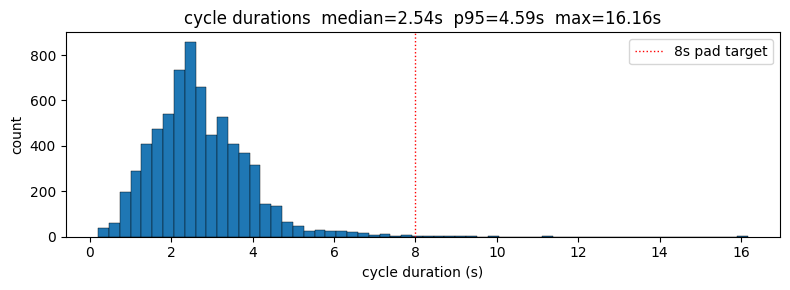

count    6898.00
mean        2.70
std         1.17
min         0.20
25%         1.93
50%         2.54
75%         3.37
max        16.16

cycles <= 8s: 99.8%  (cyclic padding fills these)
cycles  > 8s: 0.2%  (will be truncated to 8s)


In [10]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(cycles["duration"], bins=60, edgecolor="black", linewidth=0.3)
ax.axvline(8.0, color="red", linestyle=":", linewidth=1, label="8s pad target")
ax.set_xlabel("cycle duration (s)")
ax.set_ylabel("count")
ax.set_title(
    f"cycle durations  median={cycles['duration'].median():.2f}s  "
    f"p95={cycles['duration'].quantile(0.95):.2f}s  max={cycles['duration'].max():.2f}s"
)
ax.legend()
plt.tight_layout()
plt.show()

print(cycles["duration"].describe().round(2).to_string())
share_under_8 = (cycles["duration"] <= 8.0).mean()
print(f"\ncycles <= 8s: {share_under_8:.1%}  (cyclic padding fills these)")
print(f"cycles  > 8s: {(1 - share_under_8):.1%}  (will be truncated to 8s)")

## Class distribution by split and device

In [11]:
print("cycles, class by split:")
print(pd.crosstab(cycles["class_name"], cycles["split"], margins=True))

print("\ncycles, class by device:")
print(pd.crosstab(cycles["class_name"], cycles["device"], margins=True))

cycles, class by split:
split       test  train   All
class_name                   
Both         143    363   506
Crackle      649   1215  1864
Normal      1579   2063  3642
Wheeze       385    501   886
All         2756   4142  6898

cycles, class by device:
device      AKGC417L  Litt3200  LittC2SE  Meditron   All
class_name                                              
Both             381        25        44        56   506
Crackle         1543        29        77       215  1864
Normal          1922       336       347      1037  3642
Wheeze           500       112       126       148   886
All             4346       502       594      1456  6898


## Summary

- File counts match: 920 .wav, 923 .txt (annotations, 2 metadata, train_test).
- Recording counts match the brief by device (646/87/60/127) and split (539/381).
- Cycle counts match the brief by class (3642/1864/886/506 = 6898 total).
- Patient overlap is the canonical 2-patient leak (156, 218).
- Cycle durations: most cycles are short. The **8s cyclic-padding target** from the paper covers the vast majority; only the long tail gets truncated.